In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FSS_DIR = "/home/users/mendrika/NCAST/Output/evaluation/ncast/fss"

MODELS = [
    "base",
    "noattention",
    "notimefeat",
    "t0",
    "t0_tminus1h",
    "t0_tminus1h_tminus2h",
]

MODEL_LABELS = {
    "base": "Full model",
    "noattention": "No self-attention",
    "notimefeat": "No temporal features",
    "t0": "t0 only",
    "t0_tminus1h": "t0 + t-1h",
    "t0_tminus1h_tminus2h": "t0 + t-1h + t-2h",
}

LEAD_TIMES = ["1", "3", "6"]

def load_fss_results():
    rows = []

    for model_name in MODELS:
        for lead_time in LEAD_TIMES:
            csv_path = os.path.join(
                FSS_DIR,
                model_name,
                f"fss_t{lead_time}.csv",
            )

            if not os.path.exists(csv_path):
                print(f"Missing: {csv_path}")
                continue

            df = pd.read_csv(csv_path)
            df["model_name"] = model_name
            df["lead_time"] = lead_time
            rows.append(df)

    return pd.concat(rows, ignore_index=True)

fss_df = load_fss_results()
fss_df.head()

,model_name,lead_time,window_px,nominal_scale_km,raw_model,raw_persistence,smooth_model,smooth_persistence,n_files_total,n_files_loaded,n_cases_used,n_cases_skipped
0,base,1,3,9,0.315025,0.290537,0.434004,0.593505,49819,49819,2370,47449
1,base,1,9,27,0.346008,0.363823,0.462120,0.635660,49819,49819,2370,47449
2,base,1,25,75,0.411115,0.540138,0.535517,0.721024,49819,49819,2370,47449
3,base,1,49,147,0.465234,0.687468,0.638515,0.808347,49819,49819,2370,47449
4,base,1,81,243,0.490911,0.779725,0.727057,0.869893,49819,49819,2370,47449


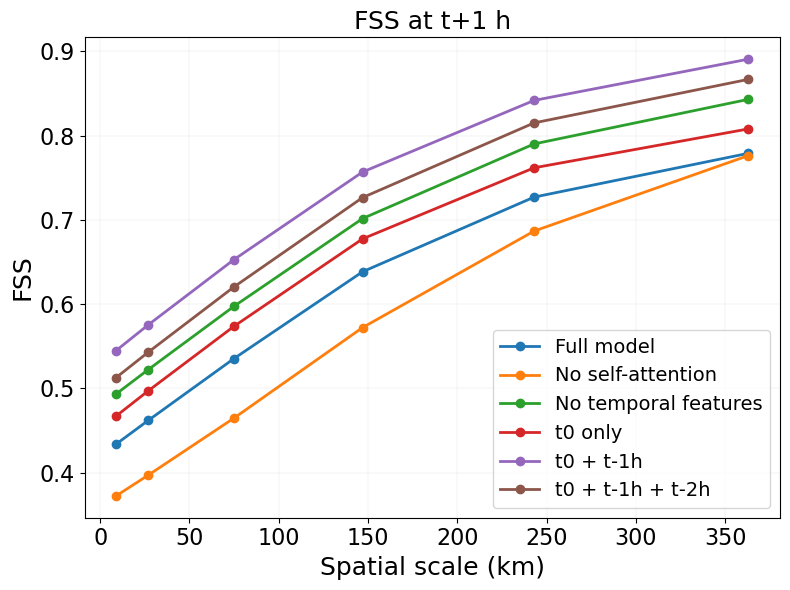

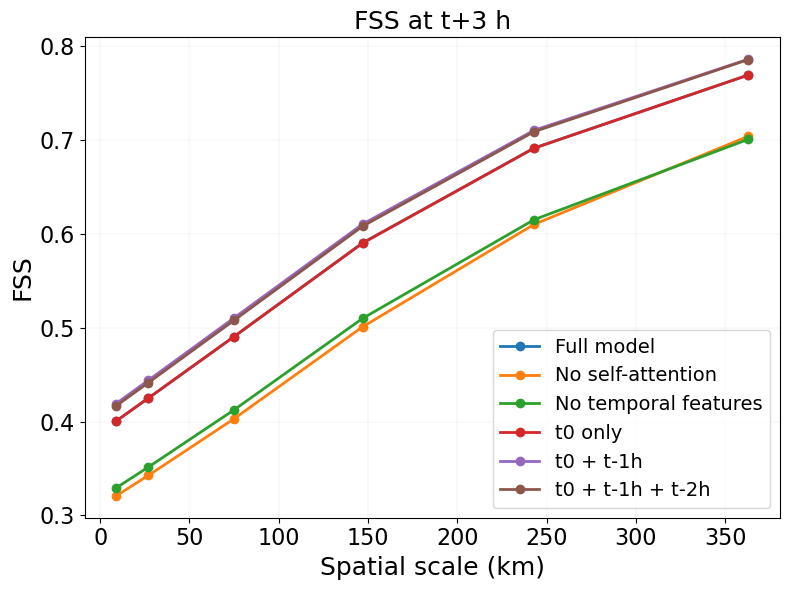

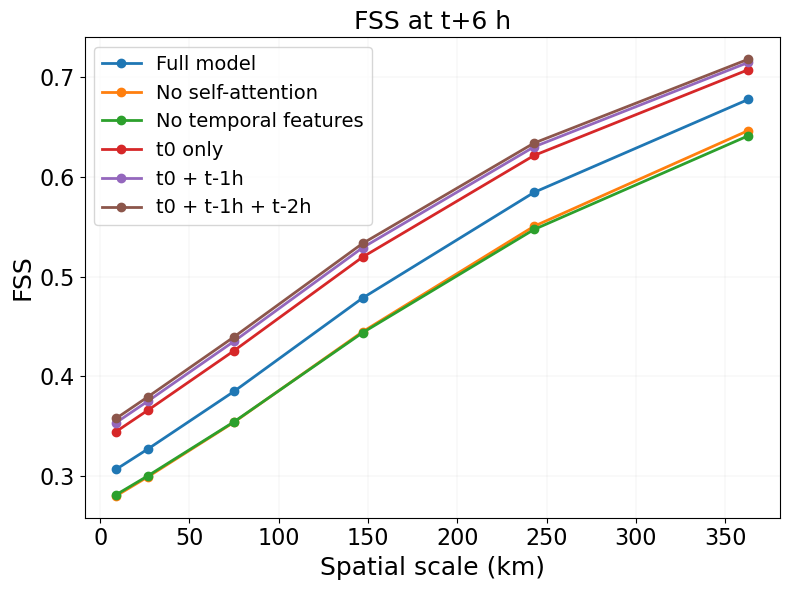

In [3]:
def plot_fss_by_lead_time(fss_df, score_col="smooth_model"):
    for lead_time in LEAD_TIMES:
        df_lt = fss_df[fss_df["lead_time"].astype(str) == lead_time]

        fig, ax = plt.subplots(figsize=(8, 6))

        for model_name in MODELS:
            df_m = df_lt[df_lt["model_name"] == model_name]

            if df_m.empty:
                continue

            ax.plot(
                df_m["nominal_scale_km"],
                df_m[score_col],
                marker="o",
                linewidth=2,
                label=MODEL_LABELS[model_name],
            )

        ax.set_title(f"FSS at t+{lead_time} h", fontsize=18)
        ax.set_xlabel("Spatial scale (km)", fontsize=18)
        ax.set_ylabel("FSS", fontsize=18)
        ax.grid(True, linewidth=0.1)
        ax.legend(fontsize=14)
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=16)

        plt.tight_layout()
        plt.show()

plot_fss_by_lead_time(fss_df, score_col="smooth_model")

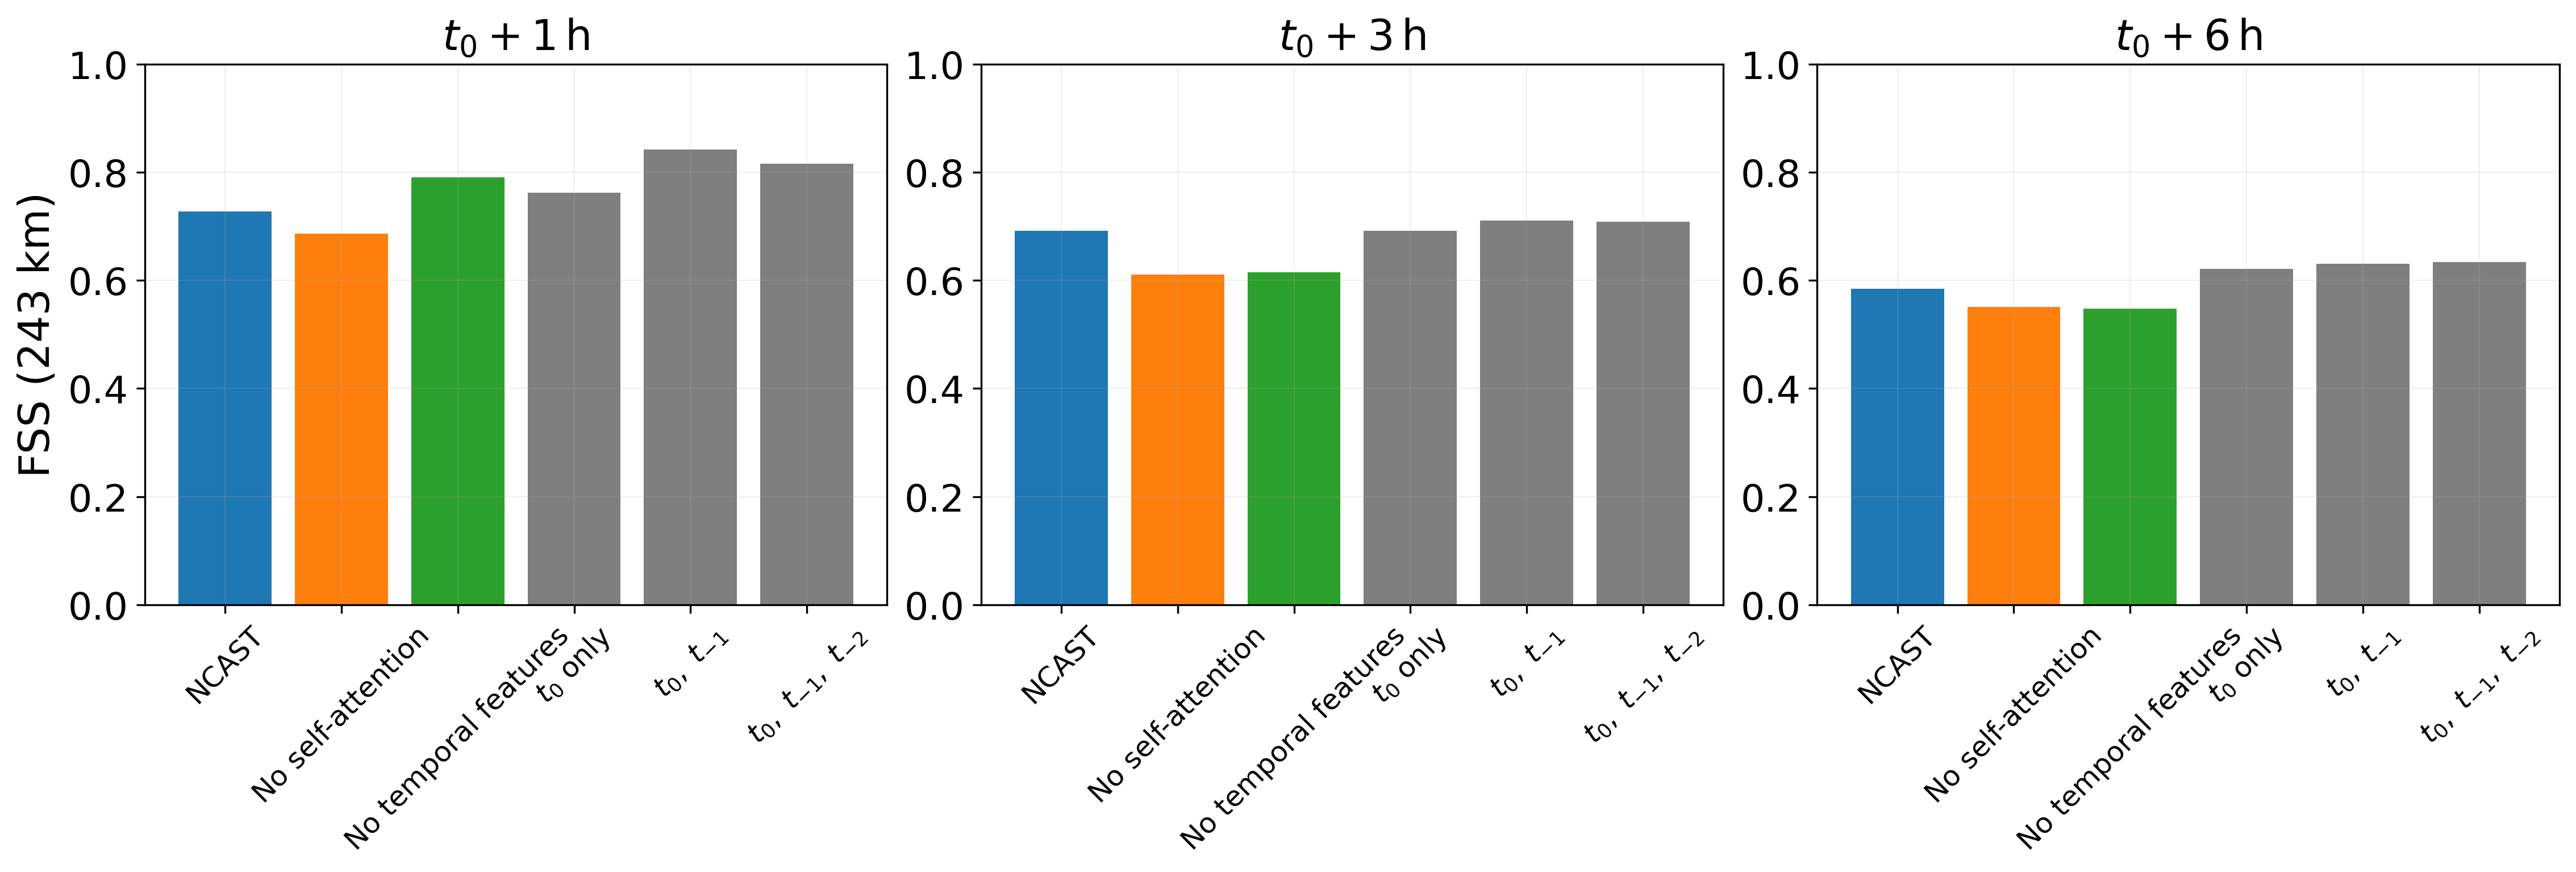

In [6]:
FSS_DIR = "/home/users/mendrika/NCAST/Output/evaluation/ncast/fss"

MODELS = [
    "base",
    "noattention",
    "notimefeat",
    "t0",
    "t0_tminus1h",
    "t0_tminus1h_tminus2h",
]

MODEL_LABELS = {
    "base": "NCAST",
    "noattention": "No self-attention",
    "notimefeat": "No temporal features",
    "t0": r"$t_0$ only",
    "t0_tminus1h": r"$t_0,\ t_{-1}$",
    "t0_tminus1h_tminus2h": r"$t_0,\ t_{-1},\ t_{-2}$",
}

LEAD_TIMES = ["1", "3", "6"]

def load_fss_results():
    rows = []

    for model_name in MODELS:
        for lead_time in LEAD_TIMES:
            csv_path = os.path.join(
                FSS_DIR,
                model_name,
                f"fss_t{lead_time}.csv",
            )

            if not os.path.exists(csv_path):
                print(f"Missing: {csv_path}")
                continue

            df = pd.read_csv(csv_path)
            df["model_name"] = model_name
            df["model_label"] = MODEL_LABELS[model_name]
            df["lead_time"] = int(lead_time)
            rows.append(df)

    return pd.concat(rows, ignore_index=True)

fss_df = load_fss_results()

window_px = 81
scale_km = window_px * 3

fss_plot = fss_df[fss_df["window_px"] == window_px].copy()

colors = {
    "NCAST": "#1f77b4",
    "No self-attention": "#ff7f0e",
    "No temporal features": "#2ca02c",
    r"$t_0$ only": "#7f7f7f",
    r"$t_0,\ t_{-1}$": "#7f7f7f",
    r"$t_0,\ t_{-1},\ t_{-2}$": "#7f7f7f",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    dpi=300,
    constrained_layout=True
)

for ax, lead_time in zip(axes, [1, 3, 6]):

    subset = fss_plot[
        fss_plot["lead_time"] == lead_time
    ]

    bars = ax.bar(
        subset["model_label"],
        subset["smooth_model"],
        color=[colors[label] for label in subset["model_label"]]
    )

    ax.set_ylim(0, 1)

    ax.set_title(
        rf"$t_0 + {lead_time}\,\mathrm{{h}}$",
        fontsize=18
    )

    ax.tick_params(axis="x", rotation=45, labelsize=12)
    ax.tick_params(axis="y", labelsize=16)

    ax.grid(True, linewidth=0.1)

    if lead_time == 1:
        ax.set_ylabel(f"FSS ({scale_km} km)", fontsize=18)

plt.savefig(
    f"fss_ablation_{scale_km}km.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()